Correlation Matrix:
              warehouse          item     sales
warehouse  1.000000e+00  7.276042e-15 -0.006562
item       7.276042e-15  1.000000e+00 -0.046406
sales     -6.562248e-03 -4.640608e-02  1.000000


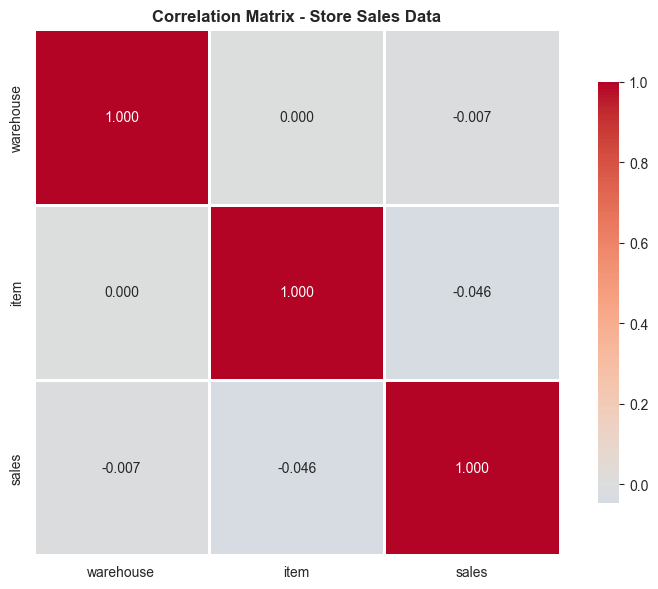


Seasonal and Time-based Analysis:

Average sales by month:
month
1     55.027303
2     54.388482
3     53.582168
4     53.368173
5     53.291677
6     53.842893
7     54.526994
8     55.314606
9     55.948693
10    56.244361
11    56.328733
12    55.643587
Name: sales, dtype: float64

Average sales by day of week (0=Monday, 6=Sunday):
day_of_week
0    44.524354
1    50.974268
2    50.401387
3    54.315693
4    58.060460
5    61.262107
6    63.984077
Name: sales, dtype: float64


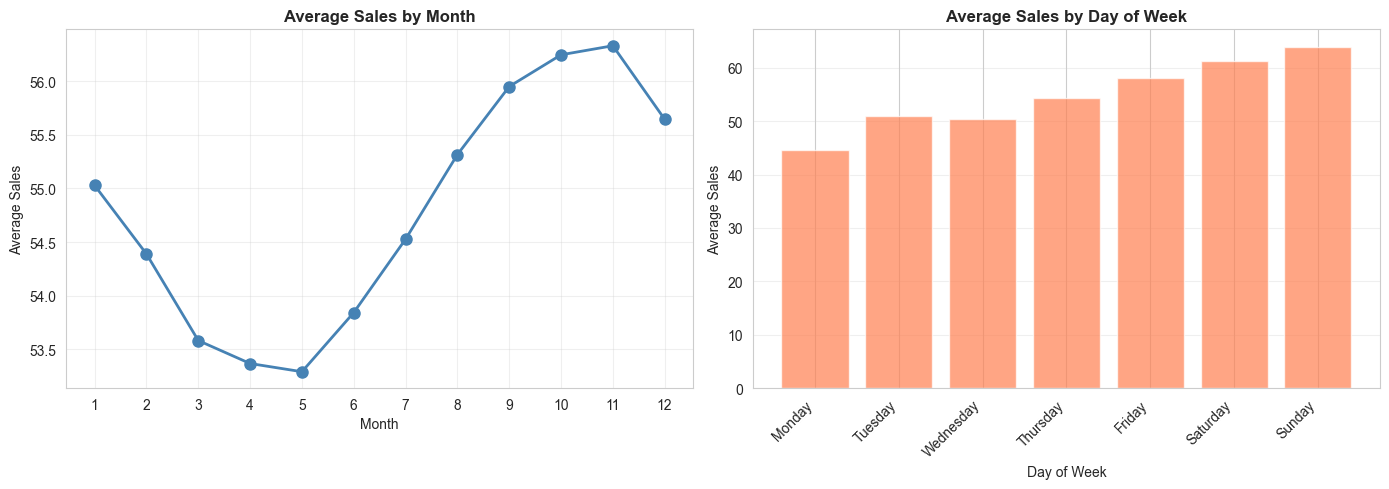


KEY INSIGHTS FROM STORE SALES EDA:
✓ Data spans 1825 days
✓ Total sales: 50,027,404 units
✓ Warehouses: 10 unique warehouses
✓ Items: 50 unique items
✓ Average daily sales per record: 54.79
✓ Sales volatility (std): 35.23
✓ Data completeness: 100.00%


In [11]:
# Correlation analysis (numerical columns)
correlation_matrix = df[['warehouse', 'item', 'sales']].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Store Sales Data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Time-based correlation
print("\nSeasonal and Time-based Analysis:")
df_with_date = df.copy()
df_with_date['year'] = df_with_date['date'].dt.year
df_with_date['month'] = df_with_date['date'].dt.month
df_with_date['day_of_week'] = df_with_date['date'].dt.dayofweek
df_with_date['quarter'] = df_with_date['date'].dt.quarter

print("\nAverage sales by month:")
monthly_avg = df_with_date.groupby('month')['sales'].mean()
print(monthly_avg)

print("\nAverage sales by day of week (0=Monday, 6=Sunday):")
dow_avg = df_with_date.groupby('day_of_week')['sales'].mean()
print(dow_avg)

# Visualize monthly and day-of-week patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly pattern
axes[0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_title('Average Sales by Month', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Day of week pattern
dow_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1].bar(dow_avg.index, dow_avg.values, color='coral', alpha=0.7)
axes[1].set_title('Average Sales by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Sales')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS FROM STORE SALES EDA:")
print("="*60)
print(f"✓ Data spans {(df['date'].max() - df['date'].min()).days} days")
print(f"✓ Total sales: {df['sales'].sum():,.0f} units")
print(f"✓ Warehouses: {df['warehouse'].nunique()} unique warehouses")
print(f"✓ Items: {df['item'].nunique()} unique items")
print(f"✓ Average daily sales per record: {df['sales'].mean():.2f}")
print(f"✓ Sales volatility (std): {df['sales'].std():.2f}")
print(f"✓ Data completeness: {(actual_records/expected_records)*100:.2f}%")
print("="*60)

## 11. XGBoost Model Training and Forecasting

In [ ]:
# Feature Engineering for XGBoost Model
# Following the backend/app/services/data_loader.py pattern

# Prepare data for XGBoost with proper feature engineering
df_xgb = df.copy()
df_xgb.sort_values('date', inplace=True)
df_xgb.reset_index(drop=True, inplace=True)

# Aggregate to daily level (sum across all warehouses and items)
daily_data = df_xgb.groupby('date')['sales'].sum().reset_index()
daily_data.sort_values('date', inplace=True)
daily_data.reset_index(drop=True, inplace=True)

print(f"Daily data shape: {daily_data.shape}")
print(f"Date range: {daily_data['date'].min()} to {daily_data['date'].max()}")

# Calendar features
daily_data['year'] = daily_data['date'].dt.year
daily_data['month'] = daily_data['date'].dt.month
daily_data['quarter'] = daily_data['date'].dt.quarter
daily_data['weekofyear'] = daily_data['date'].dt.isocalendar().week.astype(int)
daily_data['day_of_month'] = daily_data['date'].dt.day
daily_data['day_of_week'] = daily_data['date'].dt.dayofweek  # 0=Mon, 6=Sun
daily_data['week_of_month'] = (daily_data['date'].dt.day - 1) // 7 + 1

# Payday features (25th of month is payday)
daily_data['is_payday'] = (daily_data['day_of_month'] == 25).astype(int)
daily_data['is_payday_window'] = daily_data['day_of_month'].isin([24, 25, 26]).astype(int)

# Lag features (1-7 days)
for lag in range(1, 8):
    daily_data[f'lag_{lag}'] = daily_data['sales'].shift(lag)

# Rolling statistics
daily_data['rolling_mean_7'] = daily_data['sales'].rolling(7, min_periods=1).mean()
daily_data['rolling_mean_14'] = daily_data['sales'].rolling(14, min_periods=1).mean()
daily_data['rolling_std_7'] = daily_data['sales'].rolling(7, min_periods=1).std().fillna(0)

# Forward-fill NaN values from initial lag periods
daily_data.bfill(inplace=True)
daily_data.reset_index(drop=True, inplace=True)

print("\nFeature-engineered data shape:", daily_data.shape)
print("\nFeatures created:")
print(daily_data.columns.tolist())
print("\nFirst few rows with features:")
print(daily_data.head(10))

In [ ]:
# Install XGBoost if not already installed
import subprocess
import sys

try:
    import xgboost as xgb
    print("XGBoost already installed")
except ImportError:
    print("Installing XGBoost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    import xgboost as xgb
    print("XGBoost installed successfully")

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define features for XGBoost model
CALENDAR_FEATURES = ['year', 'month', 'quarter', 'weekofyear']
DAY_FEATURES = ['day_of_month', 'day_of_week', 'week_of_month', 'is_payday', 'is_payday_window']
LAG_FEATURES = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
                'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']

all_features = CALENDAR_FEATURES + DAY_FEATURES + LAG_FEATURES

# Remove rows with NaN (mostly from initial lag periods)
df_train = daily_data.dropna(subset=all_features + ['sales'])

print(f"Training data shape after removing NaNs: {df_train.shape}")
print(f"Training data date range: {df_train['date'].min()} to {df_train['date'].max()}")

# Split data into train and validation sets (80-20 split)
X = df_train[all_features]
y = df_train['sales']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

# Initialize and train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

print("\nTraining XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=10,
    verbose=False
)

print("Model training completed!")

# Make predictions
y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print("\nTraining Set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print("\nValidation Set:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE:  {val_mae:.4f}")
print(f"  R²:   {val_r2:.4f}")

# Mean Absolute Percentage Error
val_mape = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
print(f"  MAPE: {val_mape:.2f}%")
print("="*60)

In [ ]:
# Feature Importance Analysis
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Feature Importance (Top 15):")
print(feature_importance_df.head(15).to_string(index=False))

# Visualize feature importance
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 15 features
top_features = feature_importance_df.head(15)
axes[0].barh(top_features['feature'], top_features['importance'], color='steelblue', alpha=0.7)
axes[0].set_title('Feature Importance - Top 15 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Feature importance by category
feature_categories = pd.DataFrame({
    'feature': all_features,
    'importance': feature_importance,
    'category': ['Calendar']*len(CALENDAR_FEATURES) + 
                ['Day']*len(DAY_FEATURES) + 
                ['Lag/Rolling']*len(LAG_FEATURES)
})

category_importance = feature_categories.groupby('category')['importance'].sum().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1].bar(category_importance.index, category_importance.values, color=colors, alpha=0.7)
axes[1].set_title('Feature Importance by Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Importance')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Predictions vs Actual Values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation set predictions vs actual
axes[0, 0].scatter(y_val, y_val_pred, alpha=0.5, s=20, color='steelblue')
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0, 0].set_title('Validation Set: Predicted vs Actual Sales', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Actual Sales')
axes[0, 0].set_ylabel('Predicted Sales')
axes[0, 0].grid(True, alpha=0.3)

# Residuals analysis
residuals_val = y_val.values - y_val_pred
axes[0, 1].scatter(y_val_pred, residuals_val, alpha=0.5, s=20, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Sales')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].grid(True, alpha=0.3)

# Distribution of residuals
axes[1, 0].hist(residuals_val, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Time series plot of validation predictions
val_dates = df_train.iloc[len(X_train):]['date'].values
axes[1, 1].plot(val_dates, y_val.values, label='Actual', linewidth=2, alpha=0.8)
axes[1, 1].plot(val_dates, y_val_pred, label='Predicted', linewidth=2, alpha=0.8)
axes[1, 1].set_title('Validation Period: Actual vs Predicted Sales Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nResiduals Statistics:")
print(f"Mean: {residuals_val.mean():.4f}")
print(f"Std Dev: {residuals_val.std():.4f}")
print(f"Min: {residuals_val.min():.4f}")
print(f"Max: {residuals_val.max():.4f}")

In [ ]:
# Save the trained model and feature metadata
import joblib
import os
from pathlib import Path

# Create artifacts directory if it doesn't exist
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save model
model_path = artifacts_dir / 'xgboost_sales_forecast_model.joblib'
joblib.dump(xgb_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save feature metadata
metadata = {
    'calendar_features': CALENDAR_FEATURES,
    'day_features': DAY_FEATURES,
    'lag_features': LAG_FEATURES,
    'all_features': all_features,
    'training_info': {
        'train_shape': X_train.shape,
        'val_shape': X_val.shape,
        'date_range': f"{df_train['date'].min()} to {df_train['date'].max()}",
        'training_rmse': float(train_rmse),
        'validation_rmse': float(val_rmse),
        'validation_r2': float(val_r2),
        'validation_mape': float(val_mape),
    },
    'model_params': {
        'n_estimators': 500,
        'learning_rate': 0.04,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
    }
}

import json
metadata_path = artifacts_dir / 'xgboost_model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"✓ Metadata saved to: {metadata_path}")

# Save feature importance
feature_importance_df.to_csv(artifacts_dir / 'xgboost_feature_importance.csv', index=False)
print(f"✓ Feature importance saved to: {artifacts_dir / 'xgboost_feature_importance.csv'}")

print("\n" + "="*60)
print("MODEL ARTIFACTS SAVED")
print("="*60)
print(f"All artifacts are in: {artifacts_dir.absolute()}")
print("\nFiles created:")
print(f"  1. {model_path.name}")
print(f"  2. {metadata_path.name}")
print(f"  3. xgboost_feature_importance.csv")
print("="*60)

In [ ]:
# Demonstrate Model Usage for Future Forecasting
# This shows how the trained model can be used to forecast future sales

# Create future dates (next 30 days from the last date in training data)
last_date = daily_data['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Prepare future data with calendar and day features
future_df = pd.DataFrame({'date': future_dates})

future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month
future_df['quarter'] = future_df['date'].dt.quarter
future_df['weekofyear'] = future_df['date'].dt.isocalendar().week.astype(int)
future_df['day_of_month'] = future_df['date'].dt.day
future_df['day_of_week'] = future_df['date'].dt.dayofweek
future_df['week_of_month'] = (future_df['date'].dt.day - 1) // 7 + 1
future_df['is_payday'] = (future_df['day_of_month'] == 25).astype(int)
future_df['is_payday_window'] = future_df['day_of_month'].isin([24, 25, 26]).astype(int)

# For auto-regressive prediction, initialize lag features with the last values from training data
last_values = daily_data[['sales', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
                          'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']].iloc[-1].to_dict()

# Initialize with recent history
history = list(daily_data['sales'].tail(7).values)

# Generate lag features for future dates
future_predictions = []

for idx, row in future_df.iterrows():
    # Create feature row with calendar and day features
    feat_row = {
        'year': row['year'],
        'month': row['month'],
        'quarter': row['quarter'],
        'weekofyear': row['weekofyear'],
        'day_of_month': row['day_of_month'],
        'day_of_week': row['day_of_week'],
        'week_of_month': row['week_of_month'],
        'is_payday': row['is_payday'],
        'is_payday_window': row['is_payday_window'],
    }
    
    # Add lag features from recent history
    for i, lag_val in enumerate(history[-7:], 1):
        feat_row[f'lag_{i}'] = lag_val
    
    # Add rolling statistics
    feat_row['rolling_mean_7'] = np.mean(history[-7:]) if len(history) >= 7 else np.mean(history)
    feat_row['rolling_mean_14'] = np.mean(history[-14:]) if len(history) >= 14 else np.mean(history)
    feat_row['rolling_std_7'] = np.std(history[-7:]) if len(history) >= 2 else 0.0
    
    # Make prediction
    X_future = pd.DataFrame([feat_row])[all_features]
    pred = float(max(xgb_model.predict(X_future)[0], 0.0))
    
    future_predictions.append(pred)
    history.append(pred)

future_df['predicted_sales'] = future_predictions

print("30-Day Sales Forecast:")
print(future_df[['date', 'predicted_sales', 'day_of_week', 'is_payday']].to_string(index=False))

# Visualize historical data and forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Historical actual sales
ax.plot(daily_data['date'], daily_data['sales'], label='Historical Actual Sales', linewidth=2, alpha=0.8, color='steelblue')

# Future forecast
ax.plot(future_df['date'], future_df['predicted_sales'], label='30-Day Forecast', 
        linewidth=2, alpha=0.8, color='coral', linestyle='--', marker='o', markersize=4)

# Highlight payday effect
payday_dates = future_df[future_df['is_payday'] == 1]['date']
payday_sales = future_df[future_df['is_payday'] == 1]['predicted_sales']
ax.scatter(payday_dates, payday_sales, color='red', s=100, marker='*', label='Predicted Payday', zorder=5)

ax.set_title('Sales Forecast: Historical Data + 30-Day Prediction', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axvline(x=daily_data['date'].max(), color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n30-Day Forecast Summary:")
print(f"Total predicted sales: {future_df['predicted_sales'].sum():.0f} units")
print(f"Average daily sales: {future_df['predicted_sales'].mean():.2f} units")
print(f"Payday peak days ({len(payday_sales)}): {payday_sales.values}")
print(f"Historical average daily sales: {daily_data['sales'].mean():.2f} units")

## 10. Correlation Analysis and Summary Insights

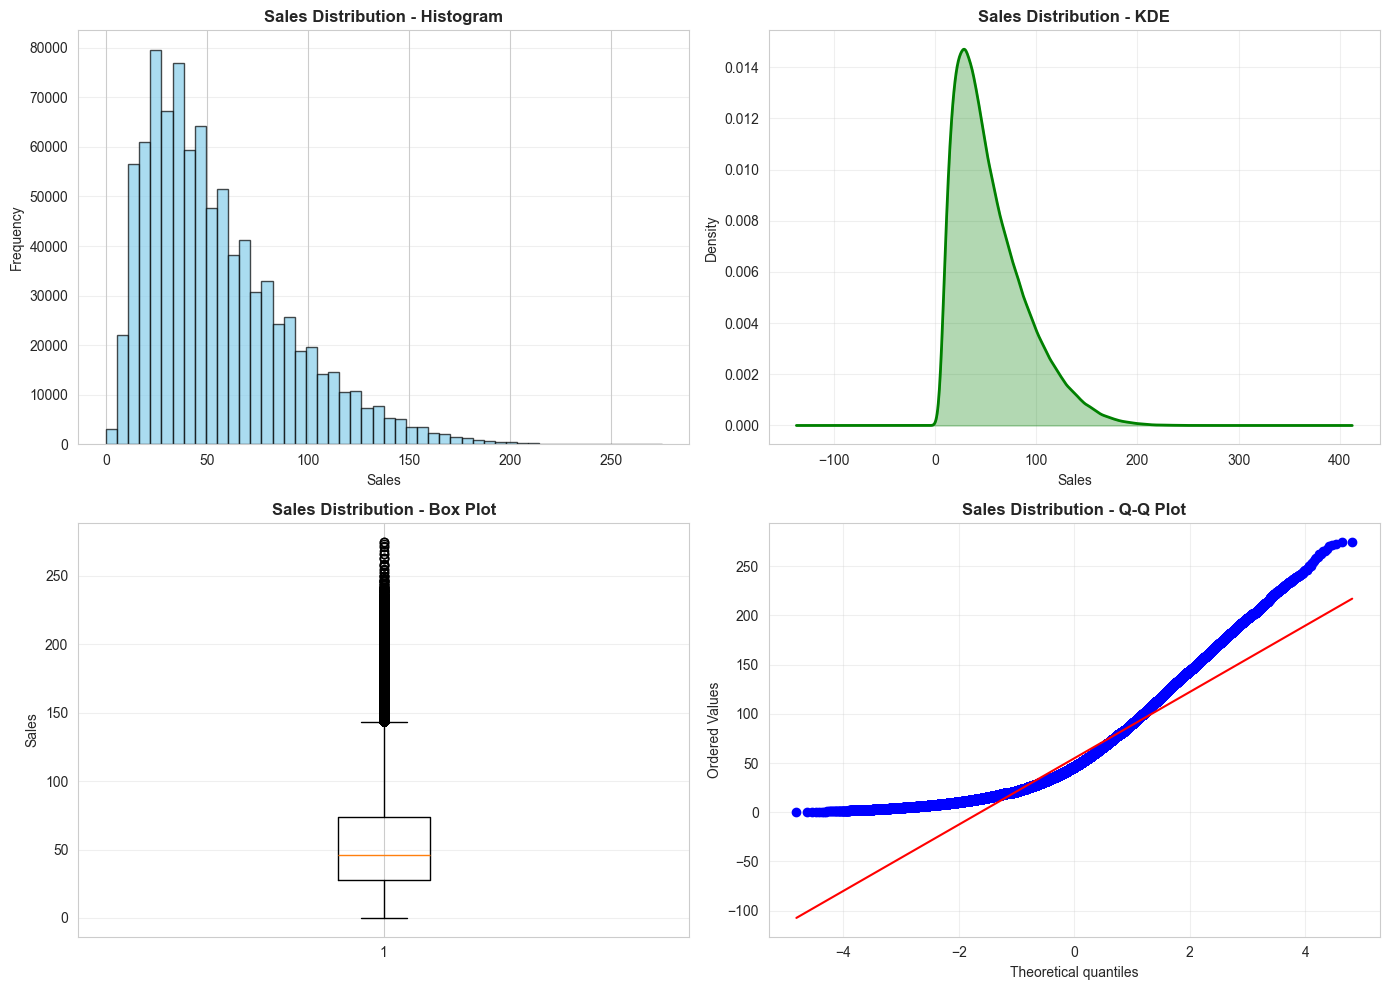

Sales Distribution Analysis:
Skewness: 1.1040
Kurtosis: 1.1233
Percentiles:
  25th percentile: 28.00
  50th percentile: 46.00
  75th percentile: 74.00
  90th percentile: 105.00
  95th percentile: 125.00
  99th percentile: 161.00

Outliers (using IQR method): 21282 records (2.33%)


In [10]:
# Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['sales'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Sales Distribution - Histogram', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# KDE plot
df['sales'].plot(kind='kde', ax=axes[0, 1], color='green', linewidth=2)
axes[0, 1].set_title('Sales Distribution - KDE', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sales')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].fill_between(axes[0, 1].get_lines()[0].get_xdata(), 
                         axes[0, 1].get_lines()[0].get_ydata(), alpha=0.3, color='green')

# Box plot
axes[1, 0].boxplot(df['sales'], vert=True)
axes[1, 0].set_title('Sales Distribution - Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Quantile-Quantile plot
from scipy import stats
stats.probplot(df['sales'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Sales Distribution - Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution statistics
print("Sales Distribution Analysis:")
print(f"Skewness: {df['sales'].skew():.4f}")
print(f"Kurtosis: {df['sales'].kurtosis():.4f}")
print(f"Percentiles:")
for percentile in [25, 50, 75, 90, 95, 99]:
    print(f"  {percentile}th percentile: {df['sales'].quantile(percentile/100):.2f}")

# Identify outliers using IQR
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['sales'] < lower_bound) | (df['sales'] > upper_bound)]
print(f"\nOutliers (using IQR method): {len(outliers)} records ({len(outliers)/len(df)*100:.2f}%)")

## 9. Distribution Analysis

Missing Values:
date         0
warehouse    0
item         0
sales        0
dtype: int64

Total missing values: 0

Total duplicate rows: 0
Duplicate entries (same date, warehouse, item): 0

Data Quality Report:
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Date continuity: No. of unique dates = 1826

Anomalies:
Zero sales records: 8
Negative sales records: 0

Expected records (all dates × warehouses × items): 913,000
Actual records: 913,000
Missing records: 0


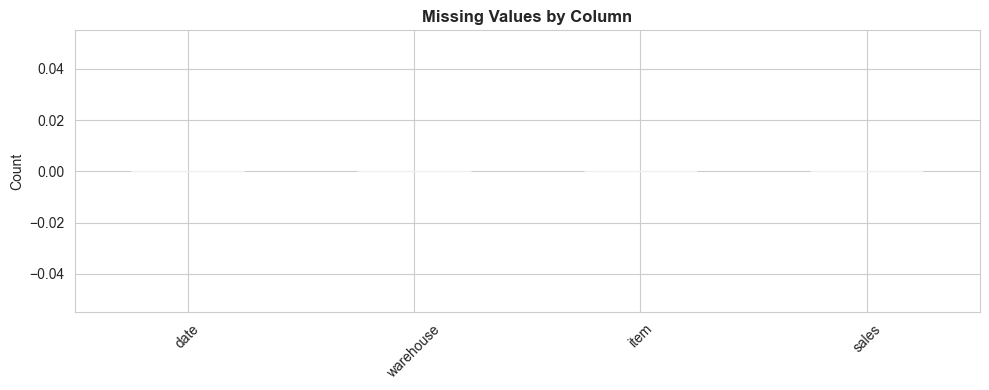

In [9]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")
duplicates_by_cols = df.duplicated(subset=['date', 'warehouse', 'item'], keep=False).sum()
print(f"Duplicate entries (same date, warehouse, item): {duplicates_by_cols}")

# Data quality summary
print("\nData Quality Report:")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Date continuity: No. of unique dates = {df['date'].nunique()}")

# Check for anomalies (negative or zero sales)
print(f"\nAnomalies:")
print(f"Zero sales records: {(df['sales'] == 0).sum()}")
print(f"Negative sales records: {(df['sales'] < 0).sum()}")

# Missing dates/expected records
date_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
expected_records = len(date_range) * df['warehouse'].nunique() * df['item'].nunique()
actual_records = len(df)
missing_records = expected_records - actual_records

print(f"\nExpected records (all dates × warehouses × items): {expected_records:,}")
print(f"Actual records: {actual_records:,}")
print(f"Missing records: {missing_records:,}")

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_data = df.isnull().sum()
missing_data.plot(kind='bar', ax=ax, color='crimson', alpha=0.7)
ax.set_title('Missing Values by Column', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Missing Values and Data Quality

Sales Statistics by Item:
          sum       mean        std  count
item                                      
28    1654112  90.586637  41.469044  18260
15    1650168  90.370646  41.625348  18260
13    1588581  86.997864  39.852523  18260
18    1584330  86.765060  39.988130  18260
38    1519876  83.235268  38.432479  18260
25    1516676  83.060022  38.429850  18260
22    1515282  82.983680  38.408799  18260
45    1515105  82.973987  38.233153  18260
36    1454541  79.657229  36.945670  18260
8     1452944  79.569770  36.826585  18260
10    1385614  75.882475  35.200143  18260
12    1322947  72.450548  33.670272  18260
29    1320152  72.297481  33.703005  18260
11    1320130  72.296276  33.720862  18260
33    1318153  72.188007  33.634811  18260


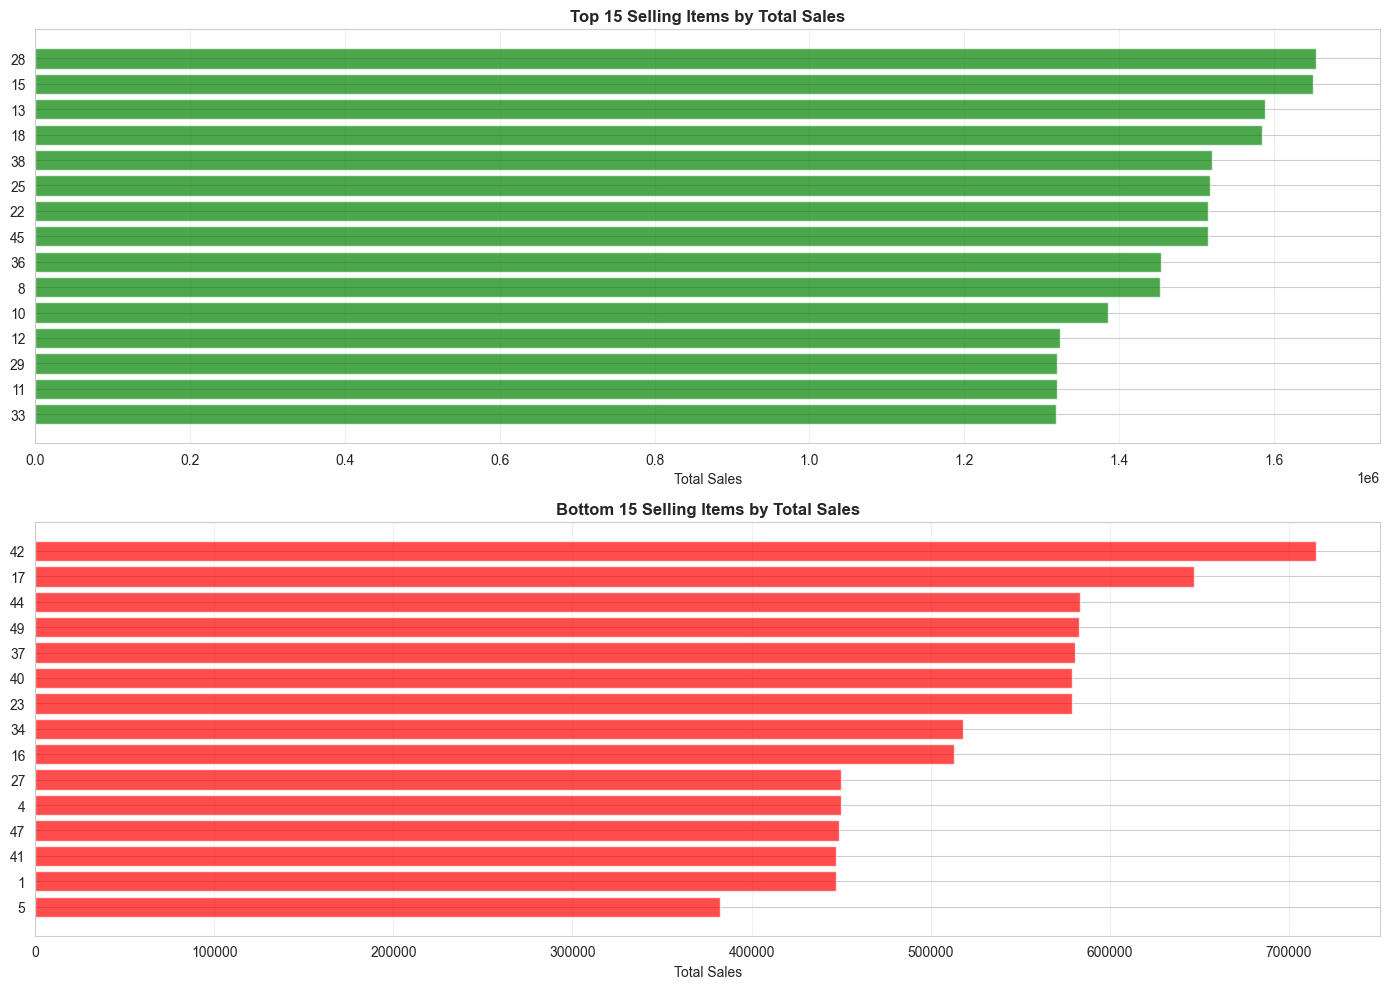


Total unique items: 50
Item with highest sales: 28 with 1,654,112 units
Item with lowest sales: 5 with 382,090 units


In [8]:
# Sales by item
item_stats = df.groupby('item')['sales'].agg(['sum', 'mean', 'std', 'count'])
item_stats = item_stats.sort_values('sum', ascending=False)

print("Sales Statistics by Item:")
print(item_stats.head(15))

# Top 15 items by total sales
top_items = df.groupby('item')['sales'].sum().sort_values(ascending=False).head(15)

# Bottom 15 items by total sales
bottom_items = df.groupby('item')['sales'].sum().sort_values(ascending=True).head(15)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top selling items
axes[0].barh(top_items.index.astype(str), top_items.values, color='green', alpha=0.7)
axes[0].set_title('Top 15 Selling Items by Total Sales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Sales')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Least selling items
axes[1].barh(bottom_items.index.astype(str), bottom_items.values, color='red', alpha=0.7)
axes[1].set_title('Bottom 15 Selling Items by Total Sales', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Sales')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nTotal unique items: {df['item'].nunique()}")
print(f"Item with highest sales: {item_stats['sum'].idxmax()} with {item_stats['sum'].max():,.0f} units")
print(f"Item with lowest sales: {item_stats['sum'].idxmin()} with {item_stats['sum'].min():,.0f} units")

## 7. Sales by Item

Sales Statistics by Warehouse:
               sum       mean        std  count
warehouse                                      
2          6347596  69.524600  41.535212  91300
8          6090786  66.711785  39.836769  91300
3          5667922  62.080197  37.260520  91300
10         5596312  61.295860  36.806857  91300
9          5254608  57.553209  34.654653  91300
4          5249239  57.494403  34.634949  91300
1          4548395  49.818127  30.400533  91300
5          3864633  42.328949  26.253344  91300
6          3859217  42.269628  26.235063  91300
7          3548696  38.868521  24.317477  91300


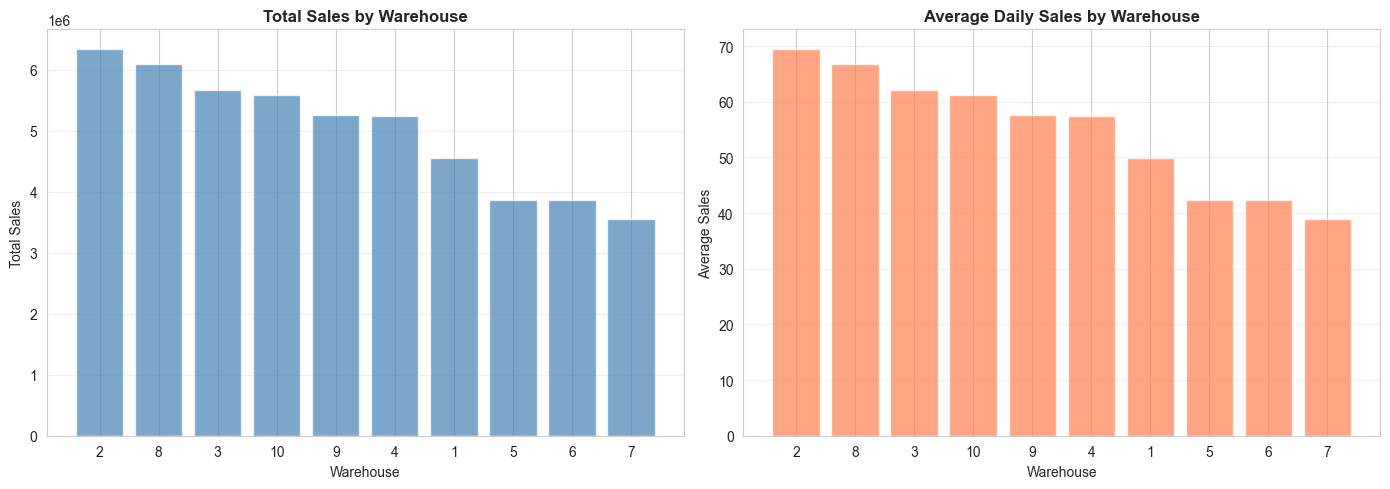

In [7]:
# Sales by warehouse
warehouse_stats = df.groupby('warehouse')['sales'].agg(['sum', 'mean', 'std', 'count'])
warehouse_stats = warehouse_stats.sort_values('sum', ascending=False)

print("Sales Statistics by Warehouse:")
print(warehouse_stats)

# Visualize warehouse sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total sales by warehouse
warehouse_sales = df.groupby('warehouse')['sales'].sum().sort_values(ascending=False)
axes[0].bar(warehouse_sales.index.astype(str), warehouse_sales.values, color='steelblue', alpha=0.7)
axes[0].set_title('Total Sales by Warehouse', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Warehouse')
axes[0].set_ylabel('Total Sales')
axes[0].grid(True, alpha=0.3, axis='y')

# Average sales by warehouse
warehouse_avg = df.groupby('warehouse')['sales'].mean().sort_values(ascending=False)
axes[1].bar(warehouse_avg.index.astype(str), warehouse_avg.values, color='coral', alpha=0.7)
axes[1].set_title('Average Daily Sales by Warehouse', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Warehouse')
axes[1].set_ylabel('Average Sales')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Sales by Warehouse

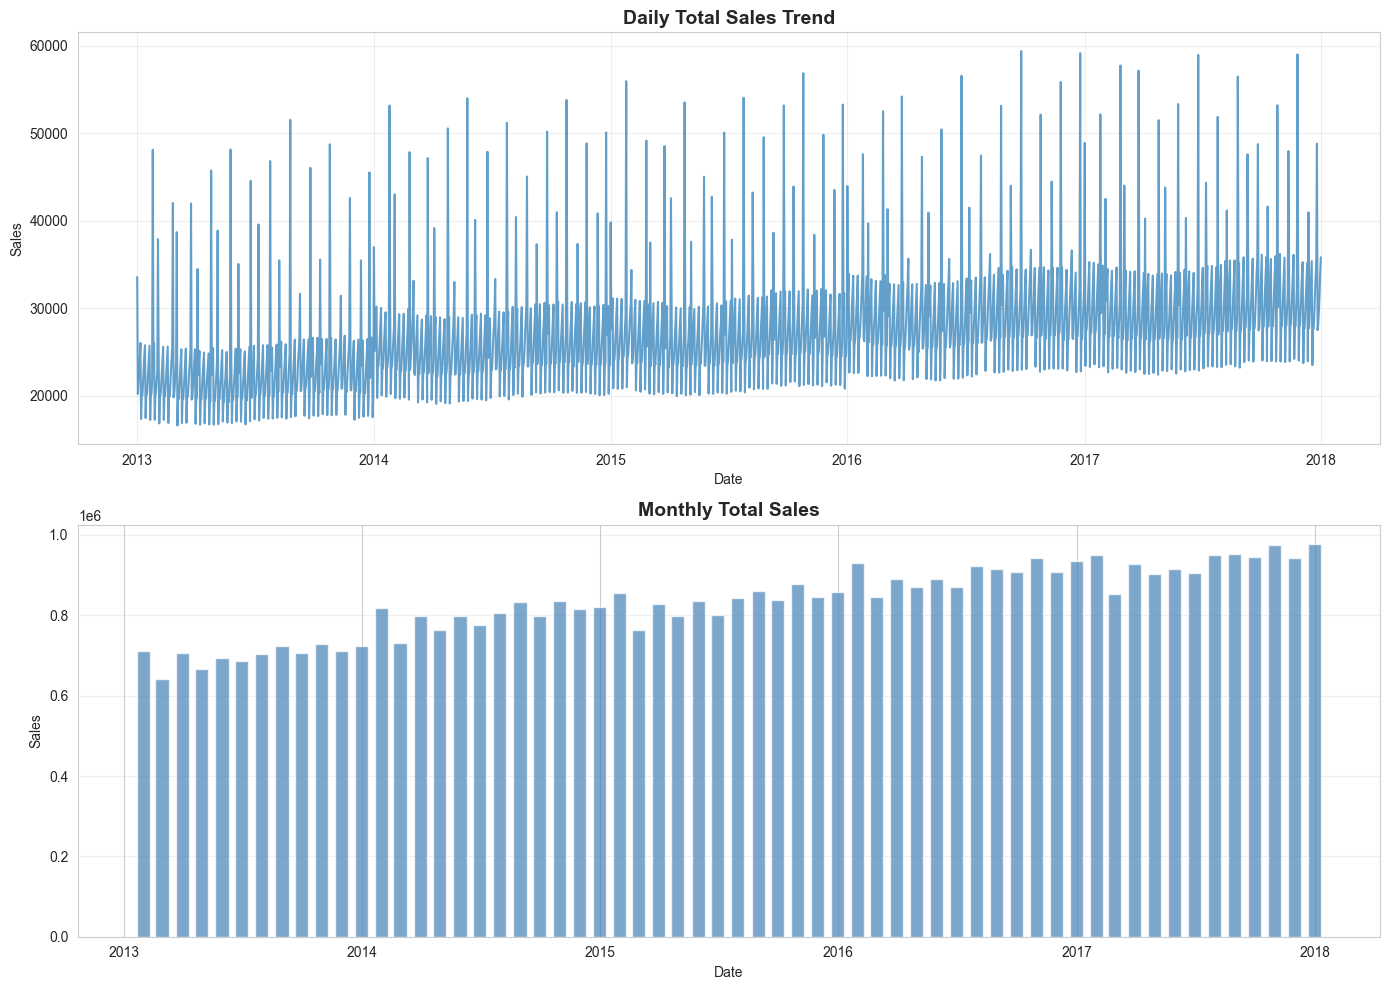

Total sales across all time: 50,027,404
Average daily sales: 27397.26
Max daily sales: 59375
Min daily sales: 16595


In [6]:
# Convert date to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df_sorted = df.sort_values('date')

# Daily total sales
daily_sales = df_sorted.groupby('date')['sales'].sum()

# Plot daily sales trend
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily sales
axes[0].plot(daily_sales.index, daily_sales.values, linewidth=1.5, alpha=0.7)
axes[0].set_title('Daily Total Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

# Monthly sales
monthly_sales = df_sorted.set_index('date').groupby(pd.Grouper(freq='M'))['sales'].sum()
axes[1].bar(monthly_sales.index, monthly_sales.values, width=20, alpha=0.7, color='steelblue')
axes[1].set_title('Monthly Total Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Total sales across all time: {daily_sales.sum():,.0f}")
print(f"Average daily sales: {daily_sales.mean():.2f}")
print(f"Max daily sales: {daily_sales.max():.0f}")
print(f"Min daily sales: {daily_sales.min():.0f}")

## 5. Time Series Analysis

In [5]:
# Descriptive Statistics
print("Descriptive Statistics for Numerical Columns:")
print(df.describe())
print("\nAdditional Statistics:")
print(f"Sales Mean: {df['sales'].mean():.2f}")
print(f"Sales Median: {df['sales'].median():.2f}")
print(f"Sales Std Dev: {df['sales'].std():.2f}")
print(f"Sales Skewness: {df['sales'].skew():.2f}")
print(f"Sales Kurtosis: {df['sales'].kurtosis():.2f}")
print(f"\nWarehouse count: {df['warehouse'].nunique()}")
print(f"Item count: {df['item'].nunique()}")

Descriptive Statistics for Numerical Columns:
           warehouse           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      54.794528
std         2.872283      14.430878      35.225851
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      28.000000
50%         5.500000      25.500000      46.000000
75%         8.000000      38.000000      74.000000
max        10.000000      50.000000     275.000000

Additional Statistics:
Sales Mean: 54.79
Sales Median: 46.00
Sales Std Dev: 35.23
Sales Skewness: 1.10
Sales Kurtosis: 1.12

Warehouse count: 10
Item count: 50


## 4. Statistical Summary

In [4]:
# Display data types and info
print("Data Types:")
print(df.dtypes)
print("\nData Info:")
df.info()
print("\n" + "="*50)
print("Non-null counts and memory usage:")
print(df.isnull().sum())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data Types:
date         object
warehouse     int64
item          int64
sales         int64
dtype: object

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   date       913000 non-null  object
 1   warehouse  913000 non-null  int64 
 2   item       913000 non-null  int64 
 3   sales      913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB

Non-null counts and memory usage:
date         0
warehouse    0
item         0
sales        0
dtype: int64

Memory usage: 72.27 MB


## 3. Data Overview and Info

In [3]:
# Load data from CSV
df = pd.read_csv('dataset/store_sales.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print(f"\nDataset spans from {df['date'].min()} to {df['date'].max()}")
print(f"Total records: {len(df):,}")

Dataset Shape: (913000, 4)

First 10 rows:
         date  warehouse  item  sales
0  2013-01-01          1     1     32
1  2013-01-02          1     1      7
2  2013-01-03          1     1      7
3  2013-01-04          1     1      8
4  2013-01-05          1     1      8
5  2013-01-06          1     1      8
6  2013-01-07          1     1      8
7  2013-01-08          1     1      7
8  2013-01-09          1     1      5
9  2013-01-10          1     1      9

Dataset spans from 2013-01-01 to 2017-12-31
Total records: 913,000


## 2. Load Data from CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 1. Import Required Libraries

# Store Sales Exploratory Data Analysis (EDA)
This notebook performs a comprehensive exploratory data analysis on the store_sales dataset to understand sales patterns, trends, and key insights.